In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from google.cloud import bigquery
from google.oauth2 import service_account

In [7]:
credentials = service_account.Credentials.from_service_account_file(
    '../credentials/gcp_credentials.json'
)
client = bigquery.Client(credentials=credentials, project='nhs-dna-analytics')

# Pull practice summary data
query = """
SELECT
    practice_code,
    icb_name,
    dna_rate,
    pct_face_to_face,
    pct_telephone,
    pct_online,
    pct_home_visit,
    pct_gp_appointments,
    avg_lead_time_days,
    total_appointments,
    is_high_dna_practice
FROM `nhs-dna-analytics.analytics.practice_summary`
WHERE total_appointments > 100
"""

df = client.query(query).to_dataframe()

print(f"Total practices: {df.shape[0]:,}")
print(f"Columns: {df.columns.tolist()}")

Total practices: 18,532
Columns: ['practice_code', 'icb_name', 'dna_rate', 'pct_face_to_face', 'pct_telephone', 'pct_online', 'pct_home_visit', 'pct_gp_appointments', 'avg_lead_time_days', 'total_appointments', 'is_high_dna_practice']


In [8]:
# Features and target
features = ['pct_face_to_face', 'pct_telephone', 'pct_online',
            'pct_home_visit', 'pct_gp_appointments', 
            'avg_lead_time_days', 'total_appointments']

X = df[features].fillna(0)
y = df['is_high_dna_practice']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"High DNA in training: {y_train.mean():.1%}")
print(f"High DNA in test: {y_test.mean():.1%}")

# Handle class imbalance
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale pos weight: {scale:.2f}")

# Train model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model.fit(X_train, y_train)
print("\nModel trained successfully")

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Normal', 'High DNA']))

Training set: 14,825 rows
Test set: 3,707 rows
High DNA in training: 13.8%
High DNA in test: 13.8%

Scale pos weight: 6.25

Model trained successfully

ROC-AUC Score: 0.7038

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.67      0.78      3196
    High DNA       0.23      0.62      0.34       511

    accuracy                           0.67      3707
   macro avg       0.57      0.65      0.56      3707
weighted avg       0.82      0.67      0.72      3707



Model saved


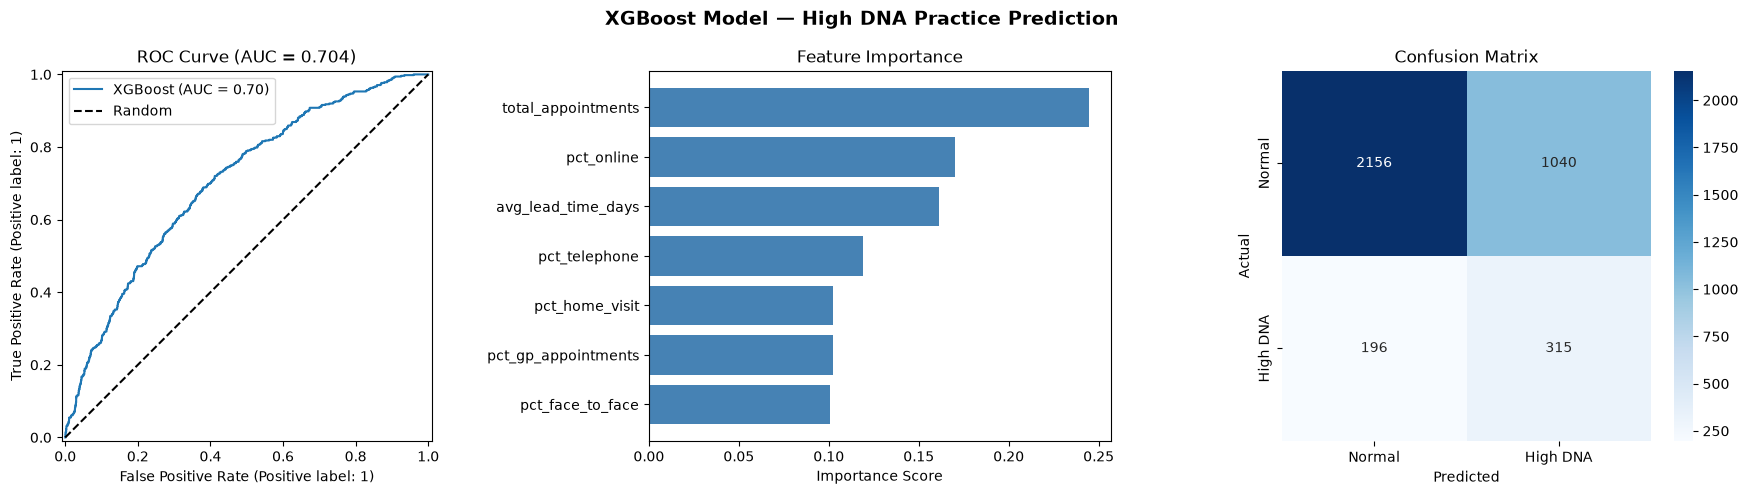


Model Summary:
ROC-AUC: 0.7038
High DNA practices correctly identified: 315 of 511
False alarms (normal flagged as high): 1040 of 3196


In [9]:
# Create output directory for model
os.makedirs('../api/model', exist_ok=True)

# Save model
joblib.dump(model, '../api/model/xgboost_dna.pkl')
print("Model saved")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Model — High DNA Practice Prediction', 
             fontsize=14, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[0], name='XGBoost'
)
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].legend()

# Feature importance
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance')

axes[1].barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2],
            xticklabels=['Normal', 'High DNA'],
            yticklabels=['Normal', 'High DNA'],
            cmap='Blues')
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../screenshots/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nModel Summary:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"High DNA practices correctly identified: {cm[1][1]} of {cm[1].sum()}")
print(f"False alarms (normal flagged as high): {cm[0][1]} of {cm[0].sum()}")

In [10]:
# Add ICB-level average DNA rate as a contextual feature
icb_query = """
SELECT
    icb_name,
    ROUND(AVG(dna_rate), 2) AS icb_avg_dna_rate
FROM `nhs-dna-analytics.analytics.practice_summary`
GROUP BY icb_name
"""

icb_df = client.query(icb_query).to_dataframe()
df = df.merge(icb_df, on='icb_name', how='left')

print("ICB average DNA rates added")
print(f"Sample:\n{df[['practice_code', 'icb_name', 'dna_rate', 'icb_avg_dna_rate']].head(10)}")

ICB average DNA rates added
Sample:
  practice_code                                           icb_name  dna_rate  \
0        J81083  NHS Bath and North East Somerset, Swindon and ...      2.08   
1        J81083  NHS Bath and North East Somerset, Swindon and ...      2.29   
2        J81083  NHS Bath and North East Somerset, Swindon and ...      1.76   
3        J83001  NHS Bath and North East Somerset, Swindon and ...      4.12   
4        J83001  NHS Bath and North East Somerset, Swindon and ...      3.26   
5        J83001  NHS Bath and North East Somerset, Swindon and ...      4.21   
6        J83002  NHS Bath and North East Somerset, Swindon and ...      5.36   
7        J83002  NHS Bath and North East Somerset, Swindon and ...      6.40   
8        J83002  NHS Bath and North East Somerset, Swindon and ...      5.40   
9        J83003  NHS Bath and North East Somerset, Swindon and ...      2.78   

   icb_avg_dna_rate  
0              3.38  
1              3.38  
2              3.

In [11]:
# Updated feature list
features_v2 = ['pct_face_to_face', 'pct_telephone', 'pct_online',
                'pct_home_visit', 'pct_gp_appointments',
                'avg_lead_time_days', 'total_appointments',
                'icb_avg_dna_rate']

X_v2 = df[features_v2].fillna(0)
y_v2 = df['is_high_dna_practice']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

scale_v2 = (y_train_v2 == 0).sum() / (y_train_v2 == 1).sum()

model_v2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_v2,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
y_pred_v2 = model_v2.predict(X_test_v2)
roc_auc_v2 = roc_auc_score(y_test_v2, y_pred_proba_v2)

print(f"V2 ROC-AUC: {roc_auc_v2:.4f} (vs {roc_auc:.4f} original)")
print(f"\nImprovement: {(roc_auc_v2 - roc_auc):.4f}")

# Save updated model
joblib.dump(model_v2, '../api/model/xgboost_dna.pkl')
print("Updated model saved")

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2,
                            target_names=['Normal', 'High DNA']))

V2 ROC-AUC: 0.8031 (vs 0.7038 original)

Improvement: 0.0993
Updated model saved

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.76      0.84      3196
    High DNA       0.32      0.69      0.43       511

    accuracy                           0.75      3707
   macro avg       0.63      0.73      0.64      3707
weighted avg       0.85      0.75      0.78      3707



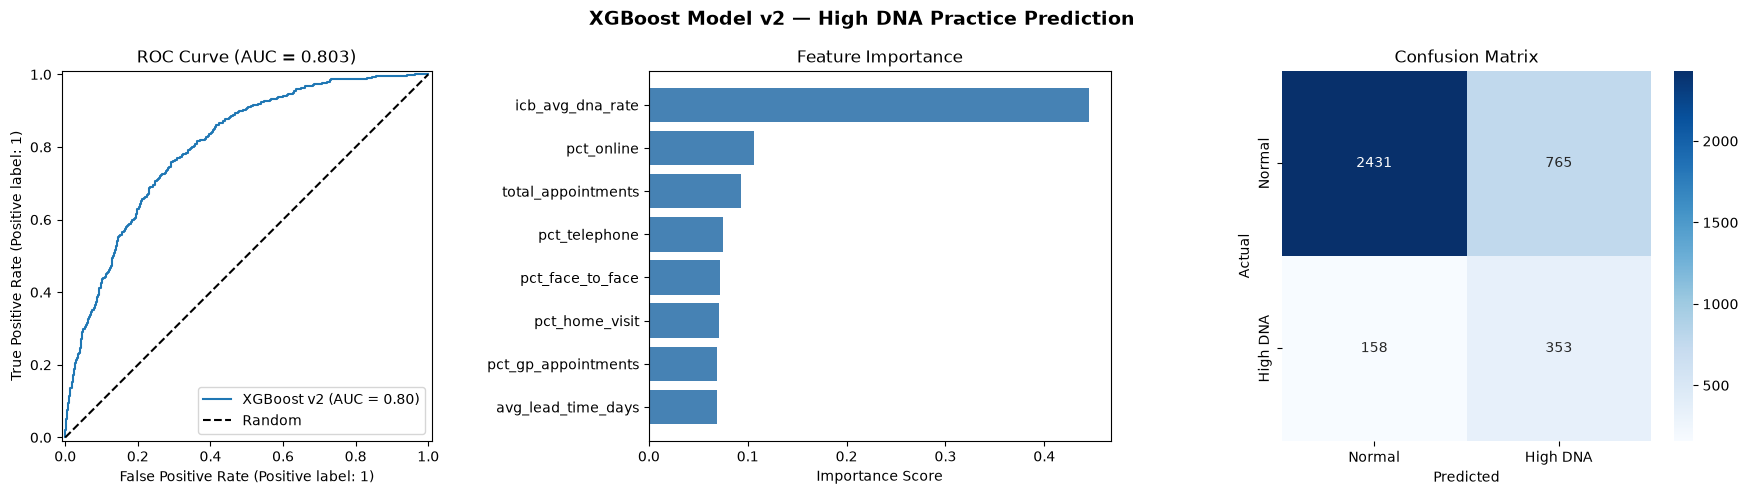


Final Model Summary:
ROC-AUC: 0.8031
High DNA practices correctly identified: 353 of 511
False alarms: 765 of 3196


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Model v2 — High DNA Practice Prediction', 
             fontsize=14, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test_v2, y_pred_proba_v2, ax=axes[0], name='XGBoost v2'
)
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc_v2:.3f})')
axes[0].legend()

# Feature importance
feat_imp = pd.DataFrame({
    'feature': features_v2,
    'importance': model_v2.feature_importances_
}).sort_values('importance')

axes[1].barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

# Confusion matrix
cm_v2 = confusion_matrix(y_test_v2, y_pred_v2)
sns.heatmap(cm_v2, annot=True, fmt='d', ax=axes[2],
            xticklabels=['Normal', 'High DNA'],
            yticklabels=['Normal', 'High DNA'],
            cmap='Blues')
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../screenshots/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Model Summary:")
print(f"ROC-AUC: {roc_auc_v2:.4f}")
print(f"High DNA practices correctly identified: {cm_v2[1][1]} of {cm_v2[1].sum()}")
print(f"False alarms: {cm_v2[0][1]} of {cm_v2[0].sum()}")